# GMM (KMeans와 비교 필요)

In [1]:
# 필요한 기능들
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

from scipy import stats
import pandas as pd
import numpy as np
from matplotlib import rc

# 경고 메세지 무시
import os
import warnings
warnings.simplefilter(action='ignore', category = FutureWarning)

# 한글 안 깨지게 하기
if os.name == 'nt' :
    font_family = "Malgun Gothic"
else :
    font_family = "AppleGothic"

sns.set(font = font_family, rc = {"axes.unicode_minus" : False})


# csv 파일 가져오기
df = pd.read_csv('data/정제데이터/동별데이터_스케일링.csv', encoding='cp949')

In [2]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 192 entries, 0 to 191
Data columns (total 10 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   시군구         192 non-null    object 
 1   행정동         192 non-null    object 
 2   기초수급자_인구밀도  192 non-null    float64
 3   저소득층_비율     192 non-null    float64
 4   총생활인구       192 non-null    float64
 5   초미세먼지       192 non-null    float64
 6   미세먼지        192 non-null    float64
 7   인당녹지면적      192 non-null    float64
 8   총공시지가평균     192 non-null    float64
 9   평균기온(°C)    192 non-null    float64
dtypes: float64(8), object(2)
memory usage: 15.1+ KB


# 환경불평등지수
- 기초수급자_인구밀도 + (1-인당녹지면적)

In [3]:
df['환경불평등지수'] = df.기초수급자_인구밀도 + (1- df.인당녹지면적)

In [4]:
df.head(3)

,시군구,행정동,기초수급자_인구밀도,저소득층_비율,총생활인구,초미세먼지,미세먼지,인당녹지면적,총공시지가평균,평균기온(°C),환경불평등지수
0,강북구,미아동,0.191522,0.335542,0.336260,0.0,0.6,0.283271,0.410610,0.767123,0.908251
1,강북구,번1동,0.260409,0.280052,0.238526,0.0,0.6,0.688506,0.290138,0.767123,0.571903
2,강북구,번2동,0.279518,0.192972,0.149009,0.0,0.6,0.702847,0.295058,0.767123,0.576671


In [5]:
data = df[['총생활인구','환경불평등지수']]

In [6]:
import numpy as np
import pandas as pd

import matplotlib as mpl
import matplotlib.pyplot as plt
import seaborn as sns

import warnings

%matplotlib inline
%config InlineBackend.figure_format = 'retina'

mpl.rc('font', family='NanumGothic') # 폰트 설정
mpl.rc('axes', unicode_minus=False) # 유니코드에서 음수 부호 설정

# 차트 스타일 설정
sns.set(font="NanumGothic", rc={"axes.unicode_minus":False}, style='darkgrid')
plt.rc("figure", figsize=(10,8))

warnings.filterwarnings("ignore")

In [7]:
from sklearn.datasets import make_blobs
from sklearn.mixture import GaussianMixture
def visualize_cluster_plot(clusterobj, dataframe, label_name, iscenter=True):
    if iscenter :
        centers = clusterobj.cluster_centers_
        
    unique_labels = np.unique(dataframe[label_name].values)
    markers=['o', 's', '^', 'x', '*']
    isNoise=False

    for label in unique_labels:
        label_cluster = dataframe[dataframe[label_name]==label]
        if label == -1:
            cluster_legend = 'Noise'
            isNoise=True
        else :
            cluster_legend = 'Cluster '+str(label)
        
        plt.scatter(x=label_cluster['ftr1'], y=label_cluster['ftr2'], s=70,\
                    edgecolor='k', marker=markers[label], label=cluster_legend)
        
        if iscenter:
            center_x_y = centers[label]
            plt.scatter(x=center_x_y[0], y=center_x_y[1], s=250, color='white',
                        alpha=0.9, edgecolor='k', marker=markers[label])
            plt.scatter(x=center_x_y[0], y=center_x_y[1], s=70, color='k',\
                        edgecolor='k', marker='$%d$' % label)
    if isNoise:
        legend_loc='upper center'
    else: legend_loc='upper right'
    
    plt.legend(loc=legend_loc)
    plt.show()

In [8]:
def gaussian_mixture_clustering(X, n_components, init_mu=None, init_cov_mat=None, init_weights=None,
                                epsilon=1e-4, max_iter=20, random_state=100):
    from scipy.stats import multivariate_normal
    import random
    # set initial value
    if init_mu is None:
        random.seed(random_state)
        idx = random.sample(range(X.shape[0]), n_components)
        mu = X[idx,:]
    else:
        mu = init_mu
 
    if init_cov_mat is None:
        np.random.seed(random_state)
        cov_list = []
        for _ in range(n_components):
            arr = np.random.rand(X.shape[1]**2)+0.1
            temp_mat = np.triu(arr.reshape(X.shape[1], X.shape[1]))
            cov_elem = temp_mat.dot(temp_mat.T)
            cov_list.append(cov_elem)
 
        cov_mat = np.array(cov_list)
    else:
        cov_mat = init_cov_mat
 
    if init_weights is None:
        weights = np.array([1/n_components]*n_components)
    else:
        weights = init_weights
 
    objective_value = -np.infty
    objective_value_history = []
    iteration = 1
    while(iteration<max_iter):
        # E-step
        assign_prob = []
        for i,d in enumerate(X):
            assign_prob_temp = []
            for k in range(n_components):
 
                assign_prob_temp.append(weights[k]*\
                                multivariate_normal(mean=mu[k],cov=cov_mat[k]).pdf(d))
 
            assign_prob_temp = np.array(assign_prob_temp)
            assign_prob_temp = assign_prob_temp/np.sum(assign_prob_temp)
            assign_prob.append(assign_prob_temp)
 
        assign_prob = np.array(assign_prob)
 
        # M-step
        temp_sum = np.sum(assign_prob, axis=0)
        next_weights = []
        next_mu = []
        next_cov_mat = []
        for k in range(n_components):
            mu_numerator = np.sum(np.expand_dims(assign_prob[:,k],axis=1)*X, axis=0)
            next_mu_vector = mu_numerator/temp_sum[k]
            next_mu.append(next_mu_vector)
            next_weights.append(temp_sum[k]/X.shape[0])
 
            t = []
            for i,d in enumerate(X):
                tt = d-next_mu_vector
                tt = np.expand_dims(tt,axis=1)
                tt_cov = np.matmul(tt,tt.transpose())
                tt_term = assign_prob[i][k]*tt_cov
                t.append(tt_term)
            t = np.array(t)
            cov_numerator = np.sum(t,axis=0)
            next_cov_mat.append(cov_numerator/temp_sum[k])
 
        next_objective_value = 0
        for x in X:
            value = np.log(np.sum([next_weights[k]*multivariate_normal(mean=next_mu[k],cov=next_cov_mat[k]).pdf(x) 
                     for k in range(n_components)]))
            next_objective_value += value
        objective_value_history.append(next_objective_value)
        if next_objective_value-objective_value<=epsilon:
            labels = [np.argmax(x) for x in assign_prob]
            return (labels, iteration, objective_value_history)
        else:
            weights = next_weights
            mu = next_mu
            cov_mat = next_cov_mat
            objective_value = next_objective_value
        iteration += 1
    labels = [np.argmax(x) for x in assign_prob]
    return (labels, iteration, objective_value_history)

In [9]:
k=5
gmm = GaussianMixture(n_components = k, random_state = 0)
df['cluster'] = gmm.fit_predict(data)

Gulim


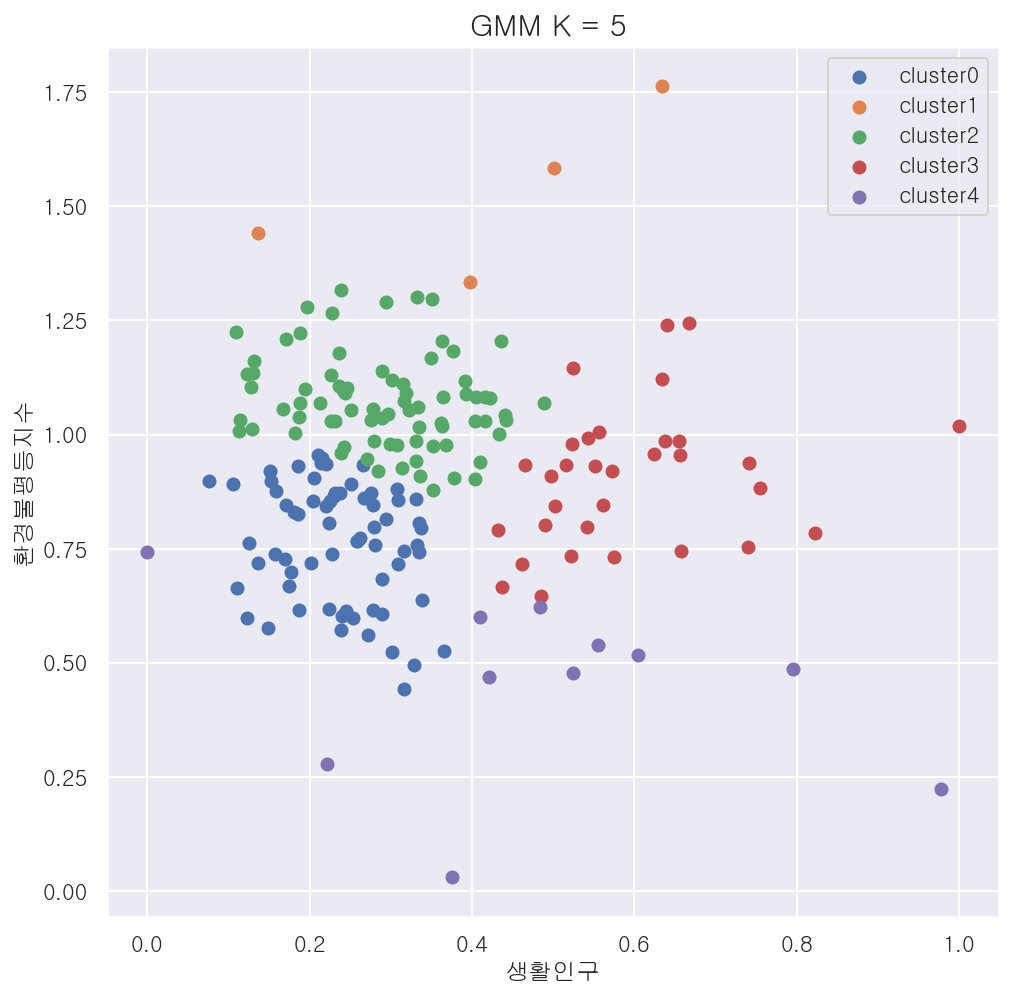

In [10]:
import matplotlib.pyplot as plt

# 한글폰트설정
font_name = 'Gulim'
print(font_name)
plt.rc('font', family=font_name)

plt.figure(figsize = (8, 8))

for i in range(k):
    plt.scatter(df.loc[df['cluster'] == i, '총생활인구'], df.loc[df['cluster'] == i, '환경불평등지수'], label = 'cluster' + str(i))

plt.legend()
plt.title('GMM K = %d '%k , size = 15)
plt.xlabel('생활인구', size = 12)
plt.ylabel('환경불평등지수', size = 12)
plt.show()

In [11]:
cluster_cnt = df.groupby('cluster').agg({'행정동':'count'}).reset_index()
cluster_des = df.groupby('cluster').mean().reset_index()

In [12]:
a = pd.merge(cluster_cnt,cluster_des)

In [13]:
import dataframe_image as dfi

dfi.export(a, './image/16-1구별_GMM_describe.png', max_cols = -1, max_rows = -1)

In [34]:
df[df.cluster==1].행정동.unique()

array(['등촌3동', '중계2·3동', '방학2동', '면목본동'], dtype=object)